In [1]:
import numpy as np
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

In [2]:
# Generate a Dataset

X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=10)

In [3]:
# List of coefficient of x1,x2....
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [4]:
# List of coefficent of Bias  -> Result (Ex -> Placed or Not)
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

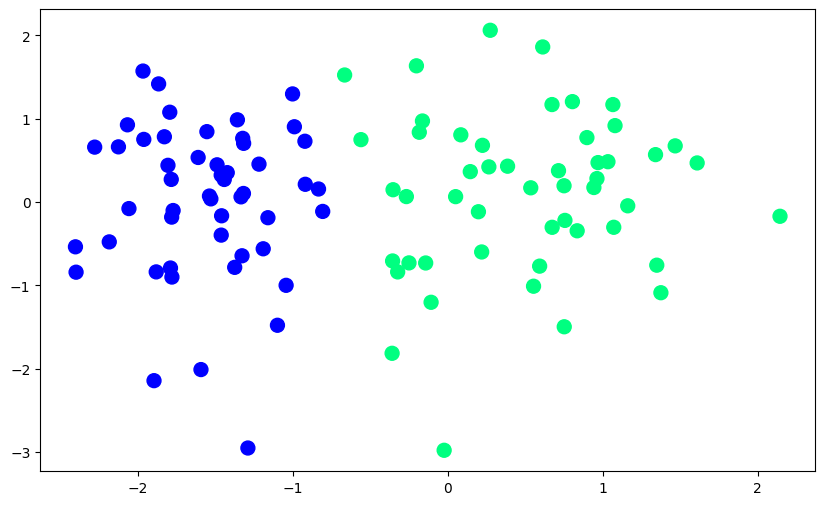

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [6]:
# Validate point position in Region

def step(z):
    # Positive -> 1
    # Negative -> 0
    return 1 if z > 0 else 0

In [7]:
# Logic

def perceptron(X,y):
    
    # Insert 1 for Bias in every row
    # b = w0.x0 --> x0 = 1
    # y = w0.(1) + w1.x1 + w2.x2
    
    X = np.insert(X,0,1,axis=1)
    
    # creating initial weight vector (List)
    # Let-> Starting Coefficient is 1. 
    # ones -> [1.,1.,1.]
    # So Line will be -> 1.1 + 1.X1 + 1.X2 --> X1 + X2 + 1 = 0
    
    weights = np.ones(X.shape[1])
    
    # Initialize Learning Rate
    lr = 0.1
    
    # Set Epochs 1000 times -> (Full pass through dataset)
    # Pass 1000 times through dataset and pick one point (student) 
    # and check its position
    for i in range(1000):
        
        # Pick Random num from 0 to 100 
        # So j -> Random row
        
        j = np.random.randint(0,100)
        
        # ******* Comparing Bias (Y Value) **********
        
        # y_hat -> Placed or Not (Position)
        #(According to Current Line -> Position is correct or Wrong)
        
        # Predict y_hat -> HOW?
        
        # Dot product of weight and Variables
        # w1.x1 + w2.X2 -> Value (> 0 or < 0)
        y_hat = step(np.dot(X[j],weights))
        
        #  ******** Updating Our Coefficient **********
        
        #   yi     yi_hat    yi - yi_hat
        #   1       1           0
        #   0       0           0
        #   1       0           1
        #   0       1          -1
        
        # Point Coordinate -> Value of Row of List X 
        # Old Coefficient (Weights) - LRate * Point (Coordinate) 
        # Update Coefficient of Current Line. -> Stored in weight
        
        # Decides Sign -> lr*(y[j]-y_hat)
        weights = weights + lr*(y[j]-y_hat)*X[j]
    
    return weights[0],weights[1:]

In [8]:
intercept_,coef_ = perceptron(X,y)

In [9]:
print(intercept_)
print(coef_)

1.0
[1.3719347 0.1029126]


In [10]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [11]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

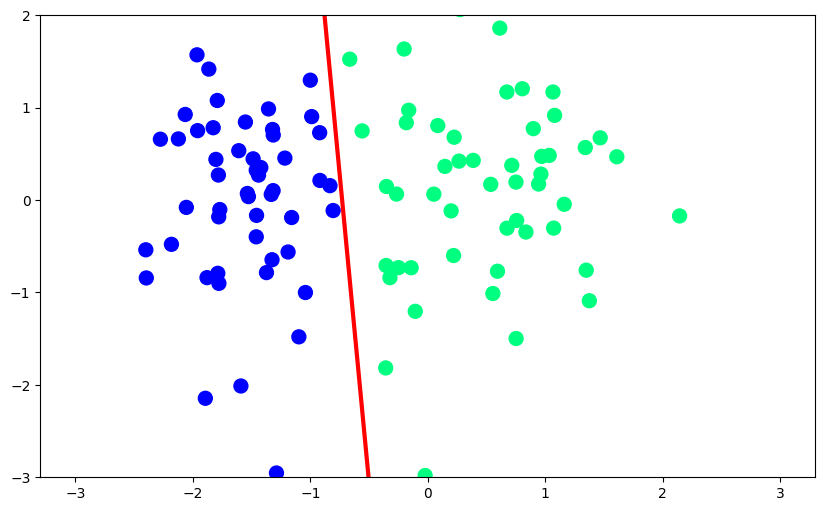

In [12]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [13]:
# Animation

def perceptron(X,y):
    
    m = []
    b = []
    # Insert Bias
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    # Initialize Learning Rate
    lr = 0.1
    
    for i in range(1000):
        # Pick Random num from 0 to 100
        j = np.random.randint(0,100)
        # Predict y_hat
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
    
    return m,b
    

In [14]:
m,b = perceptron(X,y)

In [15]:
%matplotlib widget
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

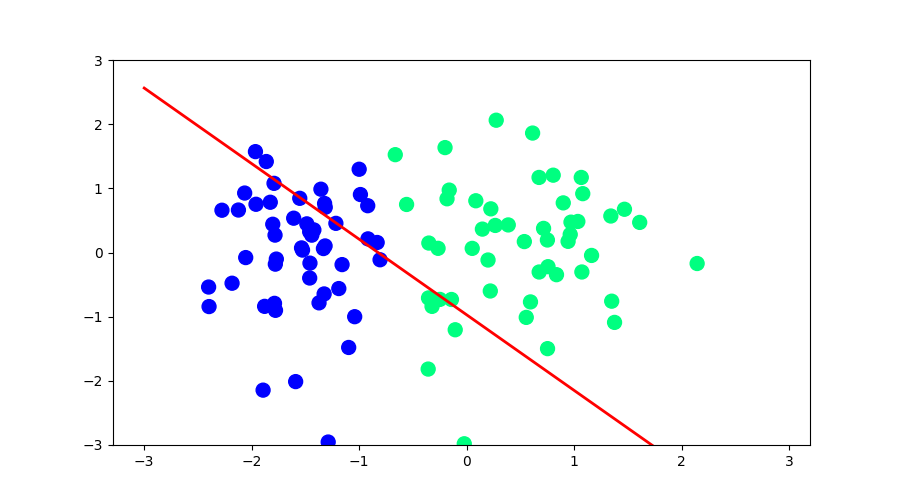

In [16]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3,3,0.1)
y_i = x_i*m[0] + b[0]

ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] + b[0], 'r-', linewidth = 2)
plt.ylim(-3,3)

def update(i):
    label = 'epoch {0}'.format(i+1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    
    
anim = FuncAnimation(fig, update, repeat = True, frames=200, interval=100)


In [17]:
# from IPython.display import HTML
# HTML(anim.to_jshtml())